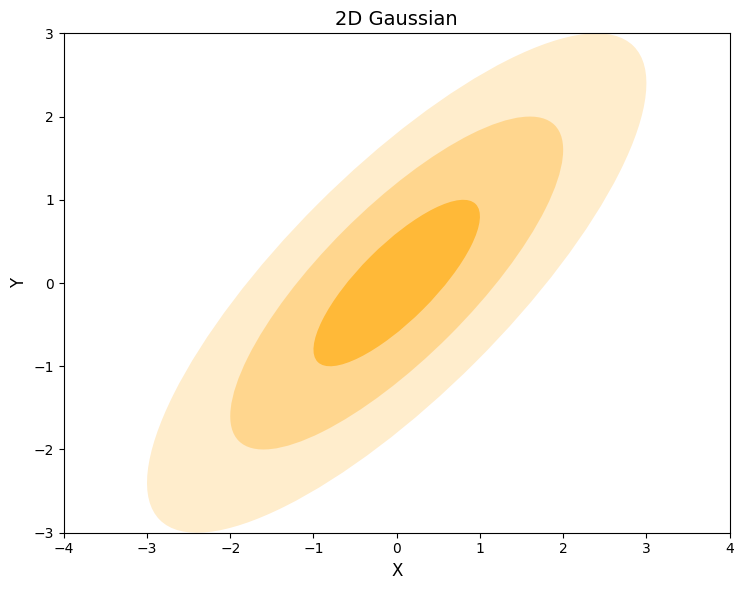

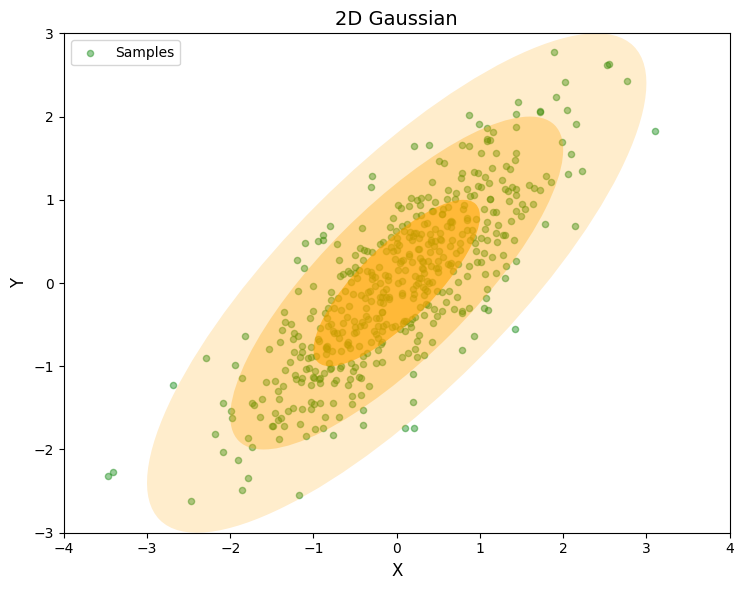

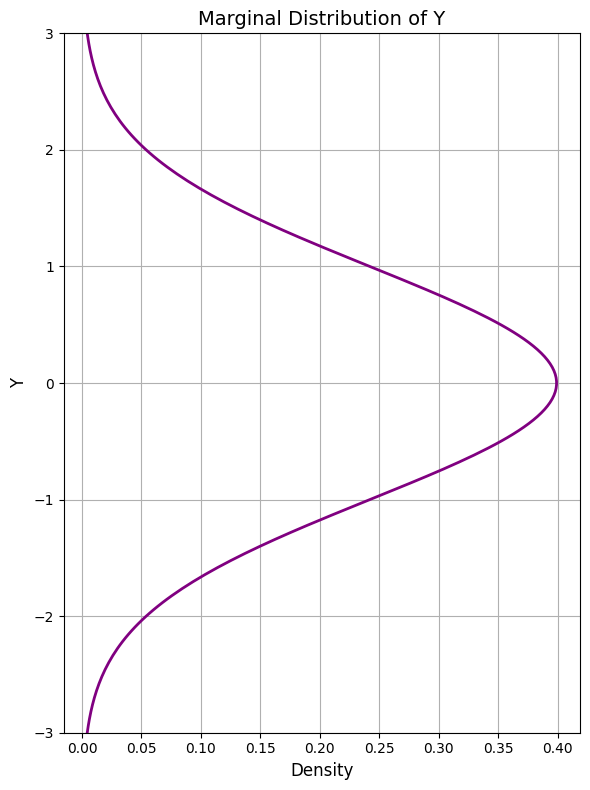

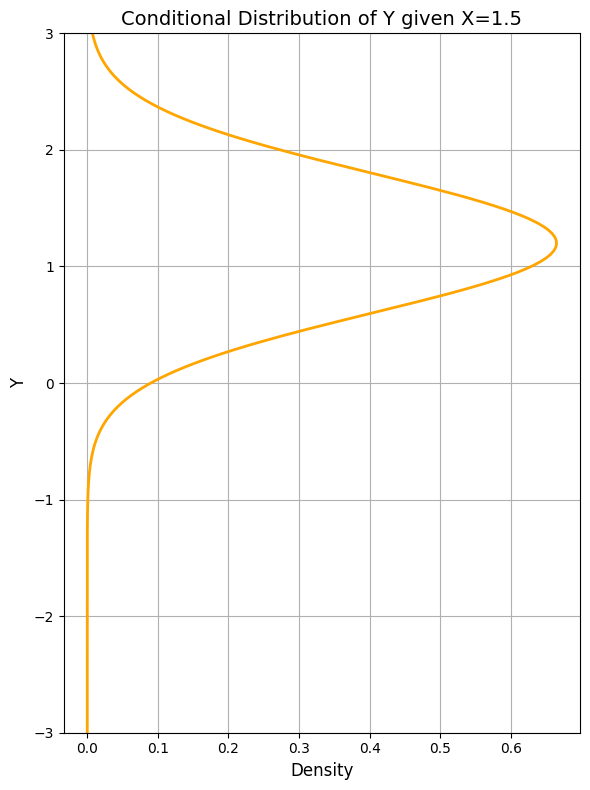

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
from matplotlib.patches import Ellipse

# Color palette:
# Purple: #800080
# Orange: #FFA500
# Green:  #008000
color_samples = '#008000'  # For samples
color_ellipse = '#FFA500'  # For ellipses

# Define the parameters of the 2D Gaussian
mean = [0, 0]
cov = [[1.0, 0.8],
       [0.8, 1.0]]  # positively correlated

# Generate a random sample
num_samples = 500
samples = np.random.multivariate_normal(mean, cov, num_samples)

# Compute eigenvalues and eigenvectors of the covariance
eigvals, eigvecs = np.linalg.eigh(cov)
angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

# Standard deviation levels for ellipses (1, 2, 3)
std_levels = [1, 2, 3]

# Common Y limits
y_min, y_max = -3, 3
x_min, x_max = -4, 4

# -------------------------
# Figure 0: 2D Gaussian with Transparent Ellipses
# -------------------------
fig, ax = plt.subplots(figsize=(8, 6))

for i, k in enumerate(std_levels):
    width, height = 2 * k * np.sqrt(eigvals)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor='none', facecolor=color_ellipse, alpha=0.6/(i+1))
    ax.add_patch(ellipse)

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('2D Gaussian', fontsize=14)
ax.set_aspect('equal', 'box')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
plt.tight_layout()
plt.show()

# -------------------------
# Figure 1: 2D Gaussian with Samples and Transparent Ellipses
# -------------------------
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(samples[:, 0], samples[:, 1], s=20, alpha=0.4, color=color_samples, label='Samples')

for i, k in enumerate(std_levels):
    width, height = 2 * k * np.sqrt(eigvals)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor='none', facecolor=color_ellipse, alpha=0.6/(i+1))
    ax.add_patch(ellipse)

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('2D Gaussian', fontsize=14)
ax.set_aspect('equal', 'box')
ax.legend()
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)  # Apply Y limits
plt.tight_layout()
plt.show()

# -------------------------
# Figure 2: Marginal Distribution of Y
# -------------------------
mean_y = 0
var_y = cov[1][1]  # This is 1.0
std_y = np.sqrt(var_y)

y_vals = np.linspace(-3, 3, 200)
pdf_marginal_y = norm.pdf(y_vals, mean_y, std_y)

fig2, ax2 = plt.subplots(figsize=(6, 8))
ax2.plot(pdf_marginal_y, y_vals, color='#800080', linewidth=2) # Purple for marginal
ax2.set_xlabel('Density', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_title('Marginal Distribution of Y', fontsize=14)
ax2.grid(True)
ax2.set_ylim(y_min, y_max)  # Apply Y limits
plt.tight_layout()
plt.show()

# -------------------------
# Figure 3: Conditional Distribution of Y given X = 1.5
# -------------------------
x0 = 1.5
# For the given parameters:
# μ_x=0, μ_y=0, σ_x=1, σ_y=1, ρ=0.8
mean_cond = 0 + 0.8 * (x0 - 0)  # 1.2
var_cond = 1 - (0.8**2)         # 0.36
std_cond = np.sqrt(var_cond)

y_cond_vals = np.linspace(-3, 3, 200)
pdf_conditional_y = norm.pdf(y_cond_vals, mean_cond, std_cond)

fig3, ax3 = plt.subplots(figsize=(6, 8))
ax3.plot(pdf_conditional_y, y_cond_vals, color='#FFA500', linewidth=2) # Orange for conditional
ax3.set_xlabel('Density', fontsize=12)
ax3.set_ylabel('Y', fontsize=12)
ax3.set_title(f'Conditional Distribution of Y given X={x0}', fontsize=14)
ax3.grid(True)
ax3.set_ylim(y_min, y_max)  # Apply Y limits
plt.tight_layout()
plt.show()

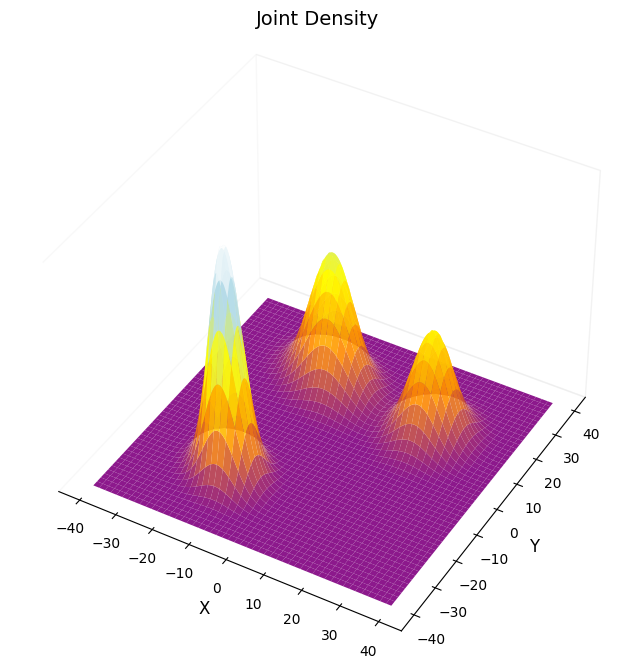

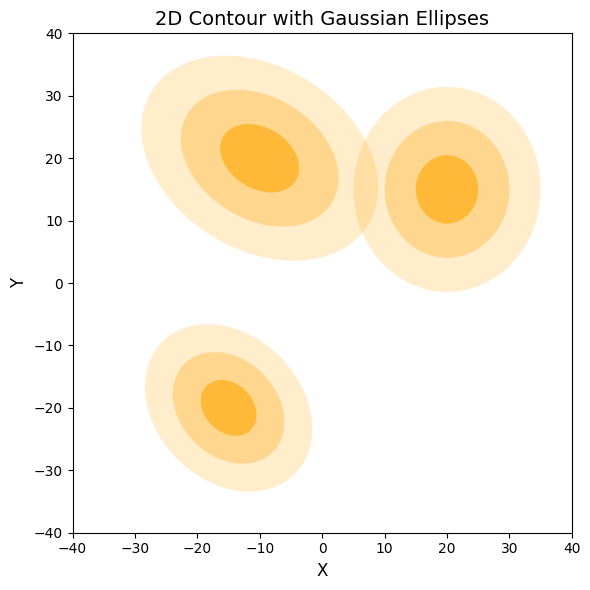

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal
from matplotlib.colors import LinearSegmentedColormap

# -------------------------
# Three Gaussian Mixture Definition (Modified)
# -------------------------
x = np.linspace(-40, 40, 300)
y = np.linspace(-40, 40, 300)
X, Y = np.meshgrid(x, y)

gaussian1 = multivariate_normal(mean=[-15, -20], cov=[[20, -5], [-5, 20]])
gaussian2 = multivariate_normal(mean=[20, 15], cov=[[25, 0], [0, 30]])
gaussian3 = multivariate_normal(mean=[-10, 20], cov=[[40, -10], [-10, 30]])

weights = [1.5, 1.0, 1.5]
weights_sum = sum(weights)
normalized_weights = [w / weights_sum for w in weights]

Z = (normalized_weights[0] * gaussian1.pdf(np.dstack((X, Y))) +
     normalized_weights[1] * gaussian2.pdf(np.dstack((X, Y))) +
     normalized_weights[2] * gaussian3.pdf(np.dstack((X, Y))))

# Create a colormap
custom_colors = [
    "#800080",  # Purple
    "#FF8C00",  # Dark Orange
    "#FFFF00",  # Yellow
    "#ADD8E6",  # Light Blue
    "#FFFFFF"   # White
]
cmap = LinearSegmentedColormap.from_list("custom_cmap", custom_colors, N=256)

# -------------------------
# 3D Plot with Joint Density (Modified)
# -------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scale the joint density
Z_scaled = Z * 8

# Plot the scaled 3D surface of the joint density
ax.plot_surface(X, Y, Z_scaled, cmap=cmap, edgecolor='none', alpha=0.9)

# Adjust viewing angle and axes
ax.view_init(elev=40, azim=-60)

# Remove Z-scale and unnecessary walls
ax.set_zticks([])  # Remove Z-axis ticks
ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))  # Make Z-axis line transparent
ax.grid(False)

# Remove background walls
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Adjust the vertical limits to reduce empty space
ax.set_zlim(0, np.max(Z_scaled) * 1)

# Update title and labels
ax.set_title('Joint Density', fontsize=14)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)

plt.show()

# -------------------------
# 2D Contour Plot with Transparent Ellipses
# -------------------------
# Define colors to match the second code
color_samples = '#008000'  # Green
color_ellipse = '#FFA500'  # Orange
color_contour = '#800080'  # Purple

fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.set_facecolor('white')  # Ensure white background
contour = ax2.contourf(X, Y, Z, levels=15, colors=[color_contour], alpha=0)

# Standard deviation levels for ellipses (1, 2, 3)
std_levels = [1, 2, 3]

gaussians = [gaussian1, gaussian2, gaussian3]
means = [[-15, -20], [20, 15], [-10, 20]]
covs = [[[20, -5], [-5, 20]], [[25, 0], [0, 30]], [[40, -10], [-10, 30]]]

for mean, cov in zip(means, covs):
    eigvals, eigvecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    
    for j, k in enumerate(std_levels):
        width, height = 2 * k * np.sqrt(eigvals)
        ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                          edgecolor='none', facecolor=color_ellipse, alpha=0.6/(j+1))
        ax2.add_patch(ellipse)

ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_title('2D Contour with Gaussian Ellipses', fontsize=14)
ax2.set_aspect('equal', 'box')
# plt.colorbar(contour)
plt.tight_layout()
plt.show()

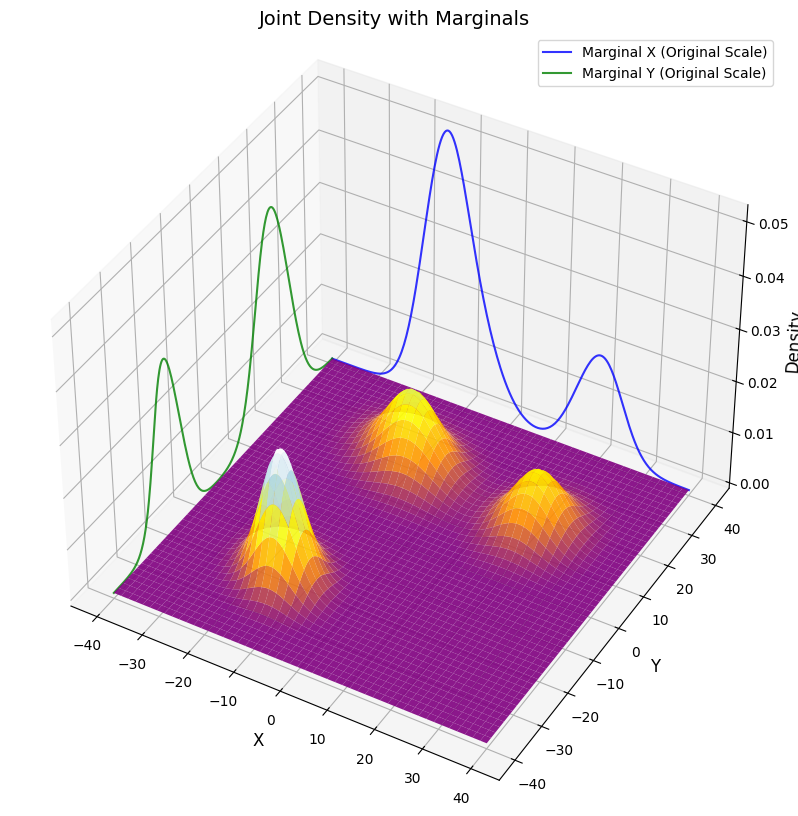

In [8]:
# -------------------------
# 3D Plot with Joint and Marginals
# -------------------------
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scale the joint density by 5 before plotting
Z_scaled = Z * 8

# Plot the scaled 3D surface of the joint density
surface = ax.plot_surface(X, Y, Z_scaled, cmap=cmap, edgecolor='none', alpha=0.9)

# Plot marginals on the walls (at original scale)
# Marginal X along the top Y wall (Y = max(y))
ax.plot(x, [y[-1]] * len(x), marginal_x, color="blue", alpha=0.8, label="Marginal X (Original Scale)")

# Marginal Y along the left X wall (X = min(x))
ax.plot([x[0]] * len(y), y, marginal_y, color="green", alpha=0.8, label="Marginal Y (Original Scale)")

# Adjust viewing angle and axes
ax.view_init(elev=40, azim=-60)

# Update title and labels
ax.set_title('Joint Density with Marginals', fontsize=14)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Density', fontsize=12)
ax.legend(loc='upper right')

plt.show()

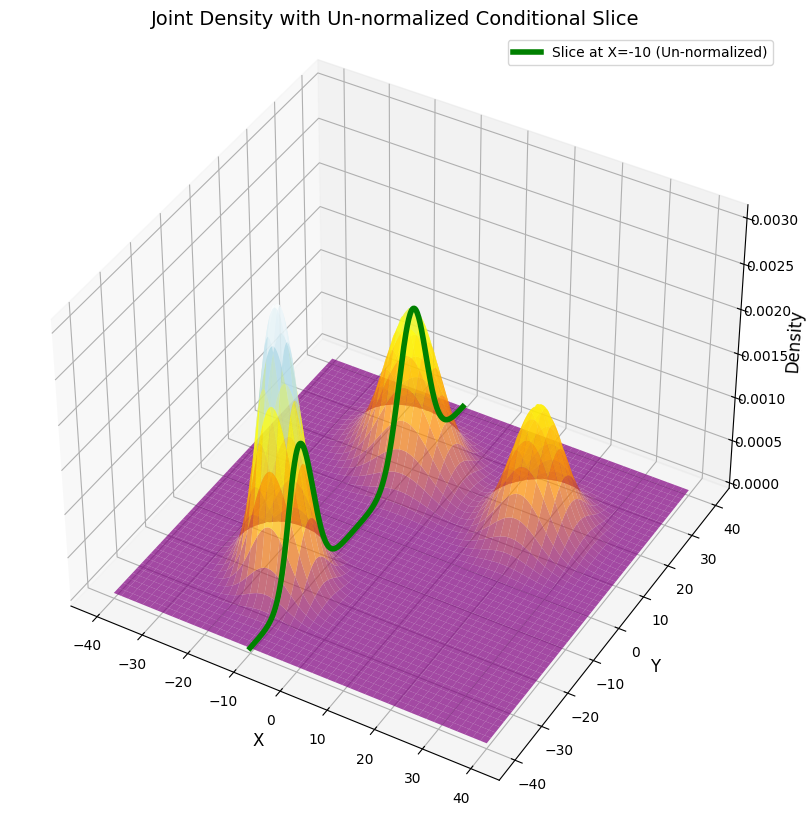

In [9]:
x0 = -10
idx_x0 = np.argmin(np.abs(x - x0))
Z_slice = Z[:, idx_x0]

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the joint density surface without scaling
ax.plot_surface(X, Y, Z, cmap=cmap, edgecolor='none', alpha=0.7, zorder=1)

# Use green color for the conditional slice
ax.plot([x0]*len(y), y, Z_slice, color='#008000', linewidth=4, 
        label=f'Slice at X={x0} (Un-normalized)', zorder=10)

ax.set_title('Joint Density with Un-normalized Conditional Slice', fontsize=14)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Density', fontsize=12)
ax.legend(loc='upper right')

# Adjust the viewing angle if needed
ax.view_init(elev=40, azim=-60)

plt.show()

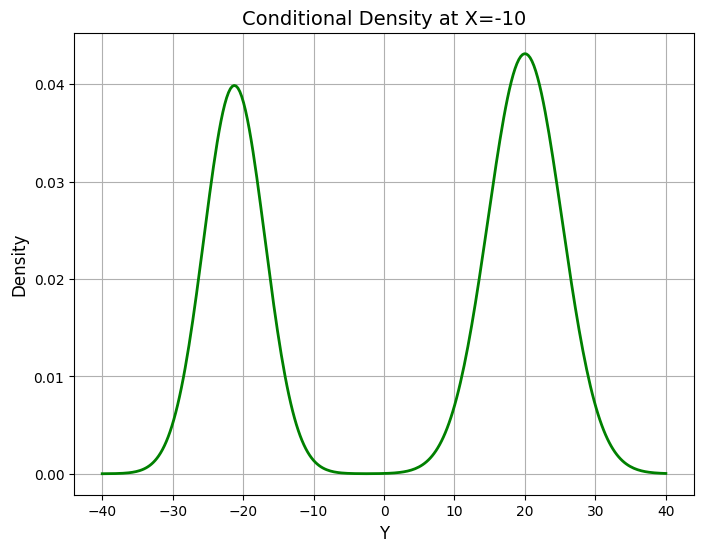

In [10]:
x0 = -10
idx_x0 = np.argmin(np.abs(x - x0))
Z_slice = Z[:, idx_x0]

# Normalize the conditional density at X = x0
Z_slice_norm = Z_slice / np.trapz(Z_slice, y)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot normalized conditional density as a 2D line plot
ax.plot(y, Z_slice_norm, color='#008000', linewidth=2)  # Using green for consistency
ax.set_title(f'Conditional Density at X={x0}', fontsize=14)
ax.set_xlabel('Y', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.grid(True)

plt.show()

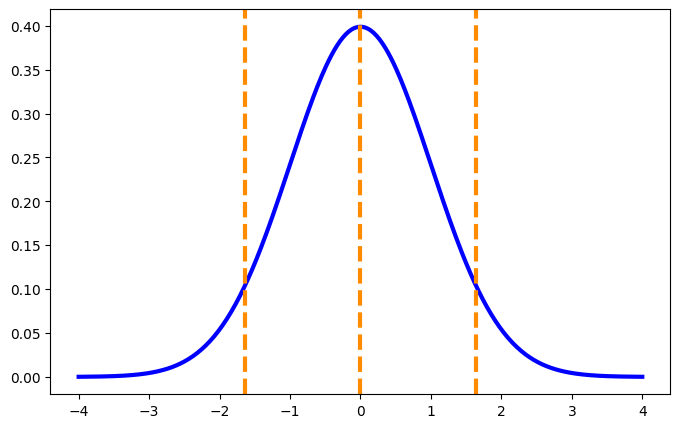

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path

# ガウス分布のパラメータ
mu = 0       # 平均
sigma = 1    # 標準偏差

# x 軸の範囲
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

# 確率密度関数（PDF）
pdf = norm.pdf(x, mu, sigma)

# 分位点
quantiles = [0.05, 0.50, 0.95]
q_values = norm.ppf(quantiles, mu, sigma)

# プロットの作成
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, pdf, color="#0000FF", linewidth=3, label="Normal Distribution")

# 分位点に線を引く
for q, val in zip(quantiles, q_values):
    ax.axvline(val, color="#FF8C00", linestyle="--", linewidth=3, label=f"{int(q*100)}% Quantile")

# 軸ラベルの設定
ax.set_xlabel("", fontsize=20)
ax.set_ylabel("", fontsize=20)

# 表示
plt.show()

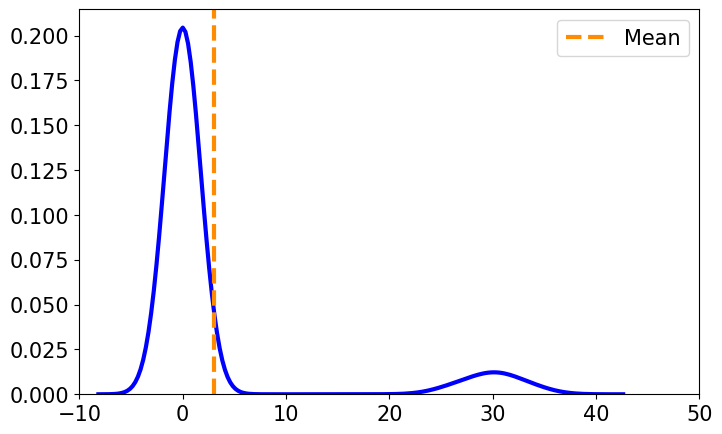

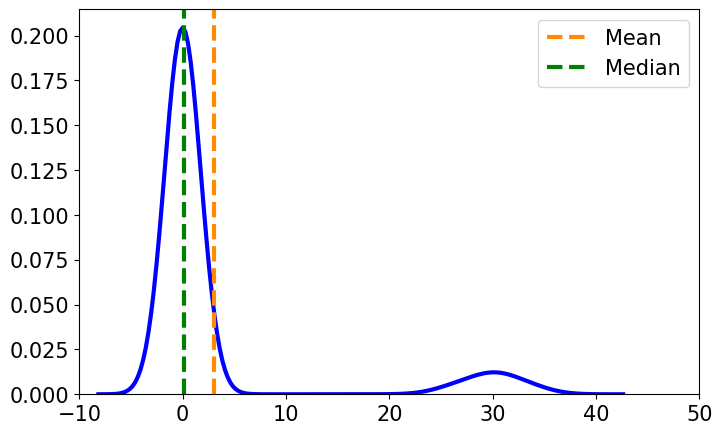

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 再現性のため乱数シードを固定
np.random.seed(42)

# データ生成
n_samples = 10000
n_outliers = int(n_samples * 0.1)
n_normal = n_samples - n_outliers

# メインの1Dガウス分布 (標準正規分布)
main_data = np.random.normal(loc=0, scale=1, size=n_normal)

# 外れ値の分布 (少し離れたガウス)
outliers = np.random.normal(loc=30, scale=3, size=n_outliers)

# データ結合
data = np.concatenate([main_data, outliers])

###########
## グラフ ##
###########
# KDEプロット
plt.figure(figsize=(8, 5))
sns.kdeplot(data, color="#0000FF", linestyle="-", linewidth=3)

# 平均値と中央値の推定
mean_estimate = np.mean(data)
median_estimate = np.median(data)

# 平均と中央値の線を描画
plt.axvline(mean_estimate, color="#FF8C00", linestyle="--", linewidth=3, label="Mean")
# plt.axvline(median_estimate, color="#008000", linestyle="--", linewidth=2, label="Median")

# 軸ラベルと凡例
plt.xlabel("", fontsize=20)
plt.ylabel("", fontsize=20)
plt.xlim(-10, 50)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)

# プロット表示
plt.show()

###########
## グラフ ##
###########
# KDEプロット
plt.figure(figsize=(8, 5))
sns.kdeplot(data, color="#0000FF", linestyle="-", linewidth=3)

# 平均値と中央値の推定
mean_estimate = np.mean(data)
median_estimate = np.median(data)

# 平均と中央値の線を描画
plt.axvline(mean_estimate, color="#FF8C00", linestyle="--", linewidth=3, label="Mean")
plt.axvline(median_estimate, color="#008000", linestyle="--", linewidth=3, label="Median")

# 軸ラベルと凡例
plt.xlabel("", fontsize=20)
plt.ylabel("", fontsize=20)
plt.xlim(-10, 50)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)

# プロット表示
plt.show()

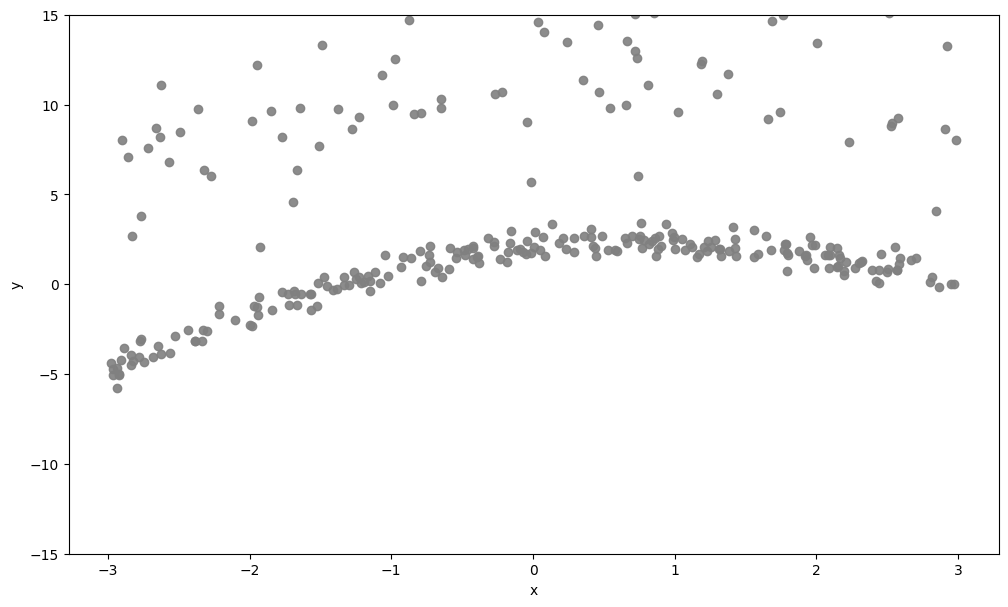

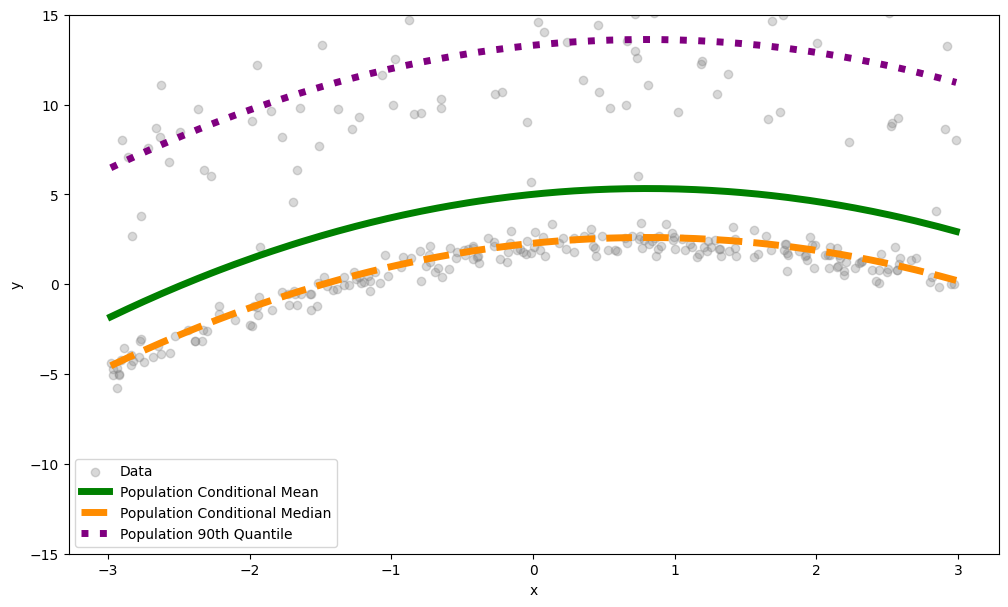

In [85]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

# Define the true underlying function f(x)
def f(x):
    return 2.0 + 0.8 * x - 0.5 * x**2

# Mixture parameters
p = 0.3  # probability of high-value component
# High-value component: Normal with mean=10, std=3
# Low-value component: Normal with mean=0, std=0.5

# Monte Carlo simulation to approximate noise population quantities:
N = 100000
r = np.random.rand(N)
noise_sample = np.where(r < p, 
                        np.random.normal(loc=10, scale=3, size=N), 
                        np.random.normal(loc=0, scale=0.5, size=N))
# Population moments and quantiles for the noise
pop_noise_mean = np.mean(noise_sample)
pop_noise_median = np.median(noise_sample)
pop_noise_q10 = np.percentile(noise_sample, 10)
pop_noise_q90 = np.percentile(noise_sample, 90)

# Generate synthetic x values and simulated responses
n = 300
x = np.sort(np.random.uniform(-3, 3, n))
# For visualization, generate one noise sample per x from the mixture
r_x = np.random.rand(n)
noise_x = np.where(r_x < p, 
                   np.random.normal(loc=10, scale=3, size=n), 
                   np.random.normal(loc=0, scale=0.5, size=n))
y = f(x) + noise_x

# Compute the population conditional curves
pop_cond_mean = f(x) + pop_noise_mean
pop_cond_median = f(x) + pop_noise_median
pop_cond_q10 = f(x) + pop_noise_q10
pop_cond_q90 = f(x) + pop_noise_q90

# -------------------------------
# Plotting the data
# -------------------------------
plt.figure(figsize=(12, 7))
# Scatter plot of the data
plt.scatter(x, y, color='#808080', alpha=0.9, label='Data')
plt.ylim(-15, 15)
plt.xlabel('x', color='#000000')
plt.ylabel('y', color='#000000')
plt.show()

# -------------------------------
# Plotting the results using the specified color palette
# -------------------------------
plt.figure(figsize=(12, 7))
# Scatter plot of the simulated data (Gray: #808080)
plt.scatter(x, y, color='#808080', alpha=0.3, label='Data')

# Plot the population conditional mean (Blue: #0000FF)
plt.plot(x, pop_cond_mean, color='#008000', linewidth=5, label='Population Conditional Mean')
# Plot the population conditional median (Dark Orange: #FF8C00)
plt.plot(x, pop_cond_median, color='#FF8C00', linestyle='--', linewidth=5, label='Population Conditional Median')
# Plot additional population quantile curves:
# 10th Quantile (Green: #008000)
# plt.plot(x, pop_cond_q10, color='#800080', linestyle=':', linewidth=5, label='Population 10th Quantile')
# 90th Quantile (Purple: #800080)
plt.plot(x, pop_cond_q90, color='#800080', linestyle=':', linewidth=5, label='Population 90th Quantile')

plt.ylim(-15, 15)
plt.xlabel('x', color='#000000')
plt.ylabel('y', color='#000000')
plt.legend()
plt.show()